# Doanh thu theo miền + ma trận BCG (loại HCM khỏi tỷ trọng)

| Metric | Định nghĩa |
|--------|------------|
| **explicit (4)** | `view_phone`, `contact_chat`, `contact_zalo`, `contact_sms` — **login only** |
| **CVR / BCG** | `explicit_per_1k_listings` = explicit / tin (mẫu số từ `dim_listing` đã prep) |
| **BCG trục** | X = `relative_cvr`; Y = `growth_cvr_pct` (H2 vs H1, cùng snapshot tin) |
| **Eligible** | `n_listings ≥ 40` và `n_explicit ≥ 20`, ex-HCM |

**Chạy nhanh:** `env/bin/python Thinh_Analyze/run_region_revenue_bcg.py`  
**Choropleth:** `env/bin/python Thinh_Analyze/run_region_choropleth.py`  
**Export:** `Thinh_Analyze/outputs/region_revenue_bcg/` (+ `maps/`)

In [15]:
%matplotlib inline
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "dim_listing").exists() and (ROOT / ".." / "dim_listing").resolve().exists():
    ROOT = (ROOT / "..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Thinh_Analyze import run_region_revenue_bcg as mod

OUT = mod.OUT_DIR
display(Markdown(f"**Output:** `{OUT}`"))

**Output:** `/Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/region_revenue_bcg`

## Chạy pipeline (hoặc đọc CSV đã export)

In [16]:
# Bỏ comment để chạy full scan (~30s)
# mod.main()

display(Markdown(Path(OUT / "SUMMARY.md").read_text(encoding="utf-8")))

# Region revenue & BCG — summary

- EDA window: `2025-11-09` → `2026-04-09` (mid `2026-01-24`)
- Explicit types (lead/CVR): view_phone, contact_chat, contact_zalo, contact_sms
- BCG metric: **CVR** = explicit / tin (`explicit_per_1k_listings`)
- BCG eligibility: `n_listings >= 50` AND `n_explicit >= 20`
- CVR growth H1→H2 uses same `n_listings` snapshot (see Cursor.md time note)
- HCM excluded from BCG median / relative CVR

## dim_listing prep
- dim prep **dim_all_5cat**: 3,107,114
- dim prep **dim_active_in_eda_window**: 52,957
- dim prep **dim_scoped_deduped**: 52,957
- dim prep **duplicate_rows_dropped**: 0

## QA
- Events category ≠ dim category rows: **0**
- Unknown region rows in revenue table: **0**

## Totals by region (explicit events)
- **Bac**: explicit=30,034, positive=273,673
- **Nam**: explicit=418,148, positive=4,803,898
- **Trung**: explicit=28,867, positive=318,475

- **HCM explicit** (reference only): 365,063

## BCG quadrant counts (eligible provinces)
- Bac / let / low_volume: 4
- Bac / sell / low_volume: 3
- Nam / let / cash_cows: 3
- Nam / let / dogs: 2
- Nam / let / question_marks: 3
- Nam / let / stars: 3
- Nam / sell / cash_cows: 5
- Nam / sell / dogs: 6
- Nam / sell / question_marks: 5
- Nam / sell / stars: 8
- Trung / let / low_volume: 5
- Trung / sell / cash_cows: 2
- Trung / sell / low_volume: 1
- Trung / sell / question_marks: 2
- Trung / sell / stars: 1

Generated by `run_region_revenue_bcg.py`.


## §1 — Doanh thu theo tỉnh × category × ad_type

In [17]:
rev = pd.read_csv(OUT / "01_revenue_by_province.csv")
summary = pd.read_csv(OUT / "02_revenue_region_category_adtype.csv")
display(Markdown("### Tổng theo miền × category × ad_type"))
display(summary.sort_values(["region", "category", "ad_type"]))
display(Markdown("### Top tỉnh explicit (Nam, let, 1050) — ex-HCM"))
sub = rev[(rev.region == "Nam") & (rev.ad_type == "let") & (rev.category == 1050) & (rev.is_hcmc == 0)]
display(sub.nlargest(10, "n_explicit_events")[["city_name", "n_explicit_events", "n_positive_events", "n_listings"]])

### Tổng theo miền × category × ad_type

,region,category,ad_type,n_listings,n_explicit_events,n_positive_events,explicit_per_1k_listings
0,Bac,1010,let,383,3815,26847,9960.835509
1,Bac,1010,sell,731,3703,34190,5065.663475
2,Bac,1020,let,323,4818,35448,14916.408669
3,Bac,1020,sell,1456,6752,77314,4637.362637
4,Bac,1030,let,406,2326,15546,5729.064039
5,Bac,1030,sell,28,80,448,2857.142857
6,Bac,1040,let,11,28,212,2545.454545
7,Bac,1040,sell,549,1739,18693,3167.577413
8,Bac,1050,let,575,6773,64975,11779.130435
9,Nam,1010,let,5068,38219,431692,7541.239148


### Top tỉnh explicit (Nam, let, 1050) — ex-HCM

,city_name,n_explicit_events,n_positive_events,n_listings
245,Bình Dương,2204,28413,142
246,Bà Rịa - Vũng Tàu,533,4170,14
247,Cần Thơ,369,6399,58
248,Đồng Nai,240,3083,19
249,Long An,132,2222,12
250,Lâm Đồng,100,1620,8
251,Tây Ninh,32,505,6
252,Đắk Lắk,20,509,10
253,Kiên Giang,20,198,3
254,Sóc Trăng,18,351,2


## §2 — Tỷ trọng ex-HCM + HCM reference

In [18]:
share = pd.read_csv(OUT / "03_share_ex_hcmc.csv")
hcmc = pd.read_csv(OUT / "hcmc_reference_stats.csv")
display(Markdown("### HCM (tham khảo — không trong BCG)"))
display(hcmc.groupby("category")[["n_explicit_events", "share_explicit_vn_pct"]].sum())
display(Markdown("### Top share miền Nam / let / 1010 (không HCM)"))
s = share[(share.region == "Nam") & (share.ad_type == "let") & (share.category == 1010) & (share.is_hcmc == 0)]
display(s.nlargest(8, "share_explicit_events_ex_hcmc_pct")[["city_name", "share_explicit_events_ex_hcmc_pct", "n_explicit_events"]])

### HCM (tham khảo — không trong BCG)

,n_explicit_events,share_explicit_vn_pct
category,,
1010,51605,10.817547
1020,167963,35.208752
1030,26903,5.639463
1040,20044,4.201665
1050,98548,20.657836


### Top share miền Nam / let / 1010 (không HCM)

,city_name,share_explicit_events_ex_hcmc_pct,n_explicit_events
92,Bình Dương,75.603070,1379
93,Cần Thơ,7.949561,145
94,Đồng Nai,5.263158,96
95,Bà Rịa - Vũng Tàu,4.550439,83
96,Long An,3.399123,62
97,Lâm Đồng,1.699561,31
98,Đắk Lắk,1.151316,21
99,Bến Tre,0.274123,5


In [19]:
for name in (
    "00_dim_listing_prep_summary.csv",
    "00_dim_listing_posted_cohort.csv",
    "00_dim_listing_by_region_category.csv",
):
    p = OUT / name
    if p.exists():
        display(Markdown(f"### `{name}`"))
        display(pd.read_csv(p))

### `00_dim_listing_prep_summary.csv`

,stage,n_rows
0,dim_all_5cat,3107114
1,dim_active_in_eda_window,52957
2,dim_scoped_deduped,52957
3,duplicate_rows_dropped,0


### `00_dim_listing_posted_cohort.csv`

,ad_status,posted_cohort,n
0,accepted,in_eda_window,42998
1,accepted,pre_eda_window,5802
2,deleted,in_eda_window,433099
3,deleted,pre_eda_window,2610137
4,hidden,in_eda_window,5695
5,hidden,pre_eda_window,1890
6,refused,in_eda_window,1145
7,refused,pre_eda_window,1901
8,shop_accepted,in_eda_window,4264
9,shop_accepted,pre_eda_window,183


### `00_dim_listing_by_region_category.csv`

,region,category,ad_type,n_listings
0,Bac,1010,let,383
1,Bac,1010,sell,731
2,Bac,1020,let,323
3,Bac,1020,sell,1456
4,Bac,1030,let,406
5,Bac,1030,sell,28
6,Bac,1040,let,11
7,Bac,1040,sell,549
8,Bac,1050,let,575
9,Nam,1010,let,5068


## §5 — Choropleth BCG (10 bản đồ: 5 category × thuê/bán)

| Trục | Định nghĩa |
|------|------------|
| **Cung** | `n_listings` (sau prep §0) |
| **Cầu** | `n_explicit_events` (4 explicit, login) |
| **CVR** | `explicit_per_1k_listings` = explicit / 1.000 tin |
| **BCG X** | `relative_cvr` (CVR tương đối trong segment, ex-HCM) |
| **BCG Y** | `growth_cvr_pct` (tăng trưởng CVR H2 vs H1) |
| **Eligible** | `n≥40`, `e≥20`; median fallback toàn quốc nếu segment &lt;2 tỉnh |
| **Màu** | 4 ô BCG; **HCM = xám** |

**Chạy:** `run_region_revenue_bcg.py` → `06_bcg_national_choropleth.csv`  
**Maps:** `run_region_choropleth.py` → `maps/fig_bcg_choropleth_{category}_{let|sell}.png`  
**Pill matrix:** `fig_bcg_pill_matrix.png` — mỗi nửa ô: `L/S` → CVR/tin → **`(n=…, e=…)`** (tin, explicit). Công thức: `08_bcg_pill_matrix_methodology.txt`. **Xám** = `n<40` hoặc `e<20`.

### Phân bố BCG CVR (toàn quốc, ex-HCM median)

bcg_quadrant      cash_cows  dogs  low_volume  question_marks  stars
category ad_type                                                    
1010     let              2     0          20               2      0
         sell             2     0          28               2      1
1020     let              2     0          35               2      1
         sell             1     4          38               1      5
1030     let              2     1          34               2      1
         sell             0     0          27               0      0
1040     let              0     0          24               0      0
         sell             3     5          39               3      6
1050     let              1     1          26               1      1

### Căn hộ — Thuê

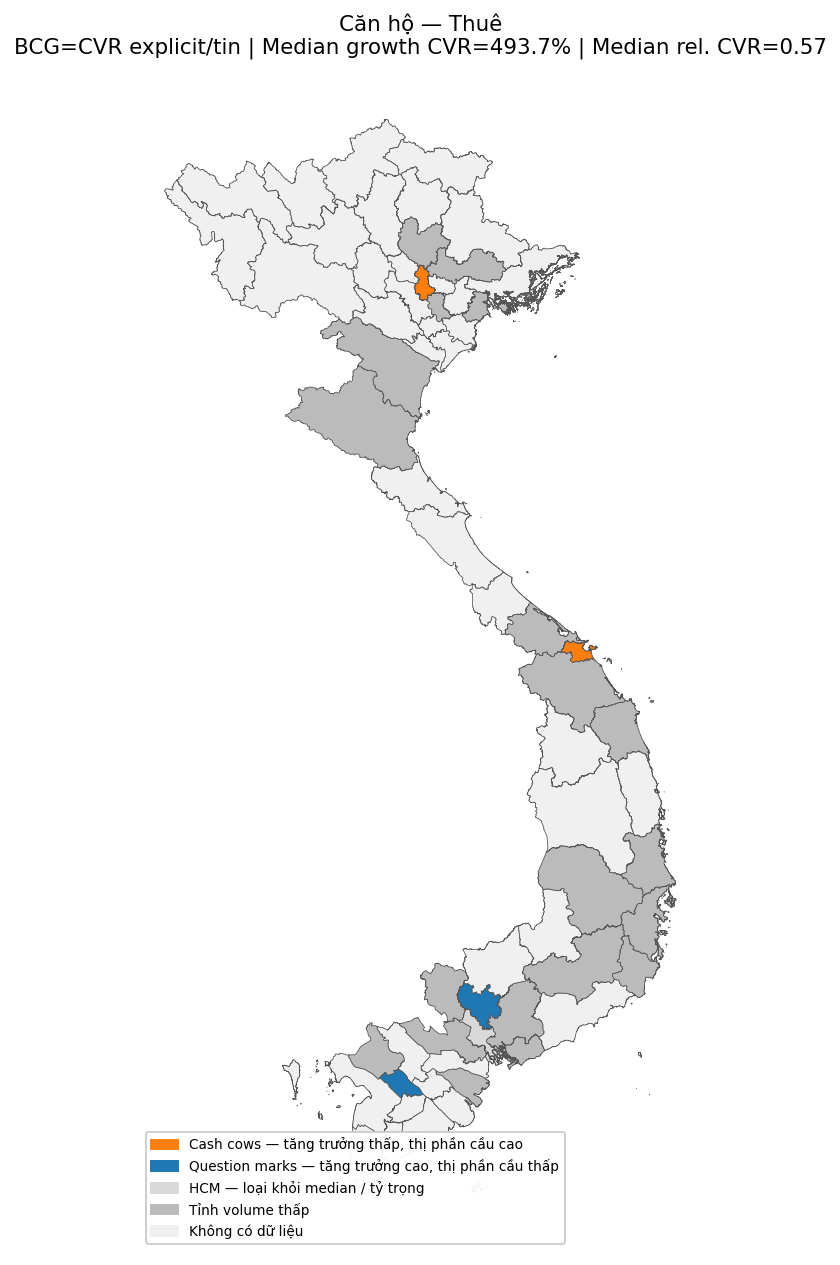

### Căn hộ — Bán

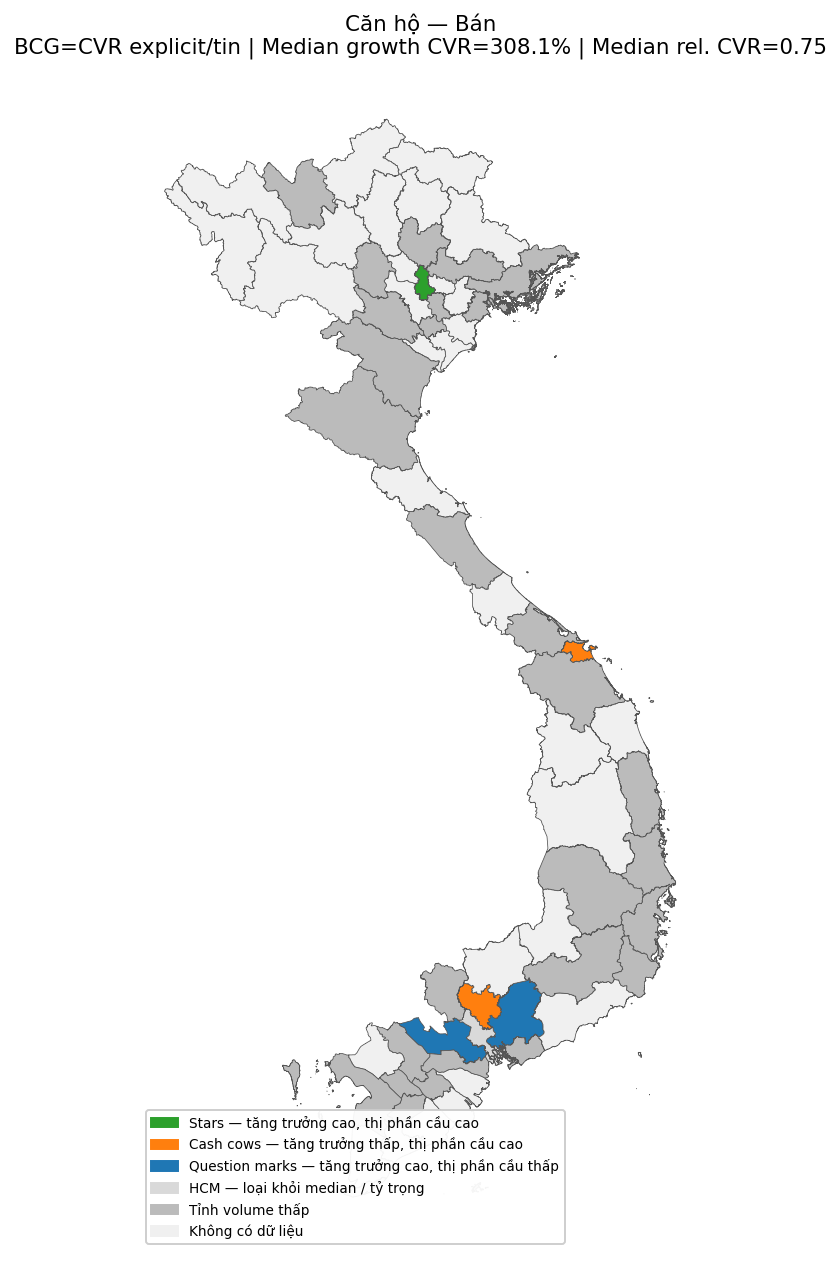

### Nhà ở — Thuê

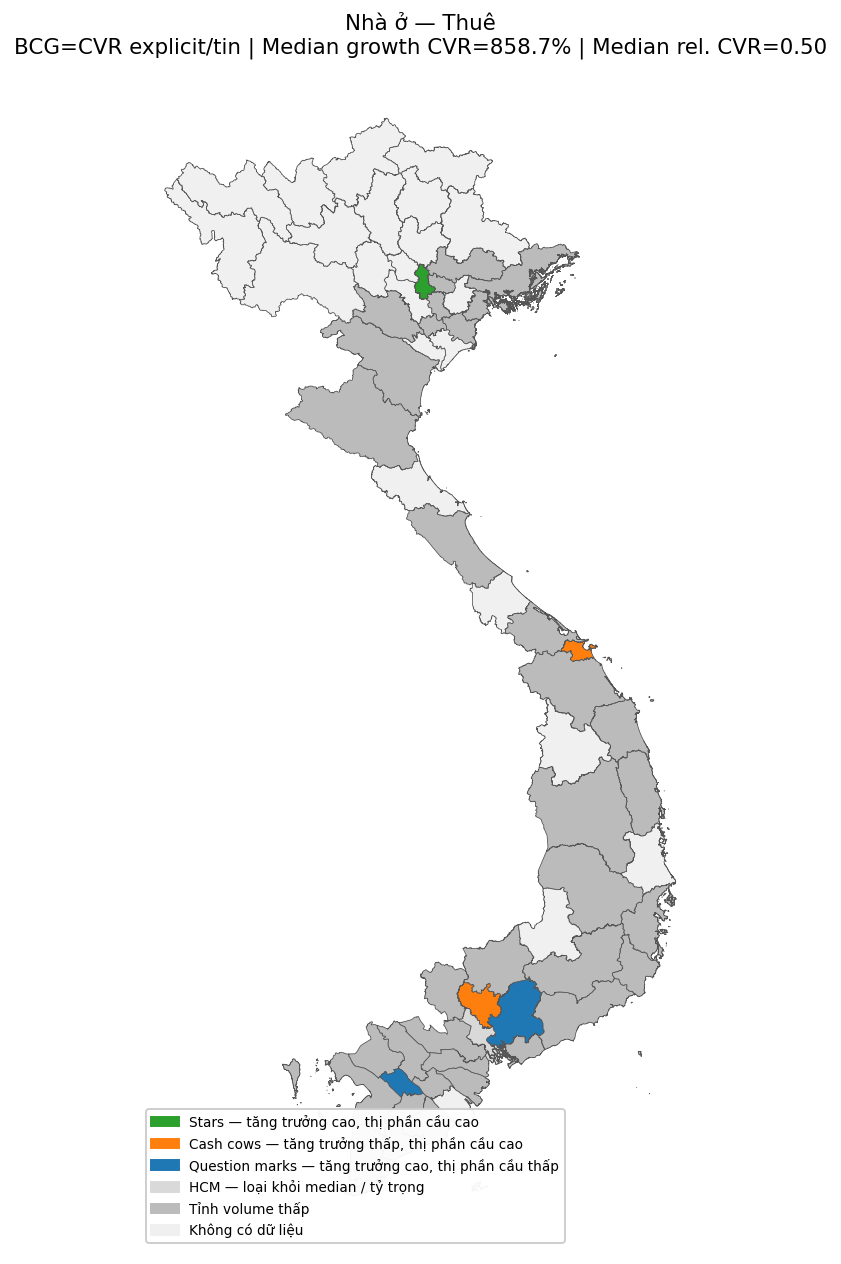

### Nhà ở — Bán

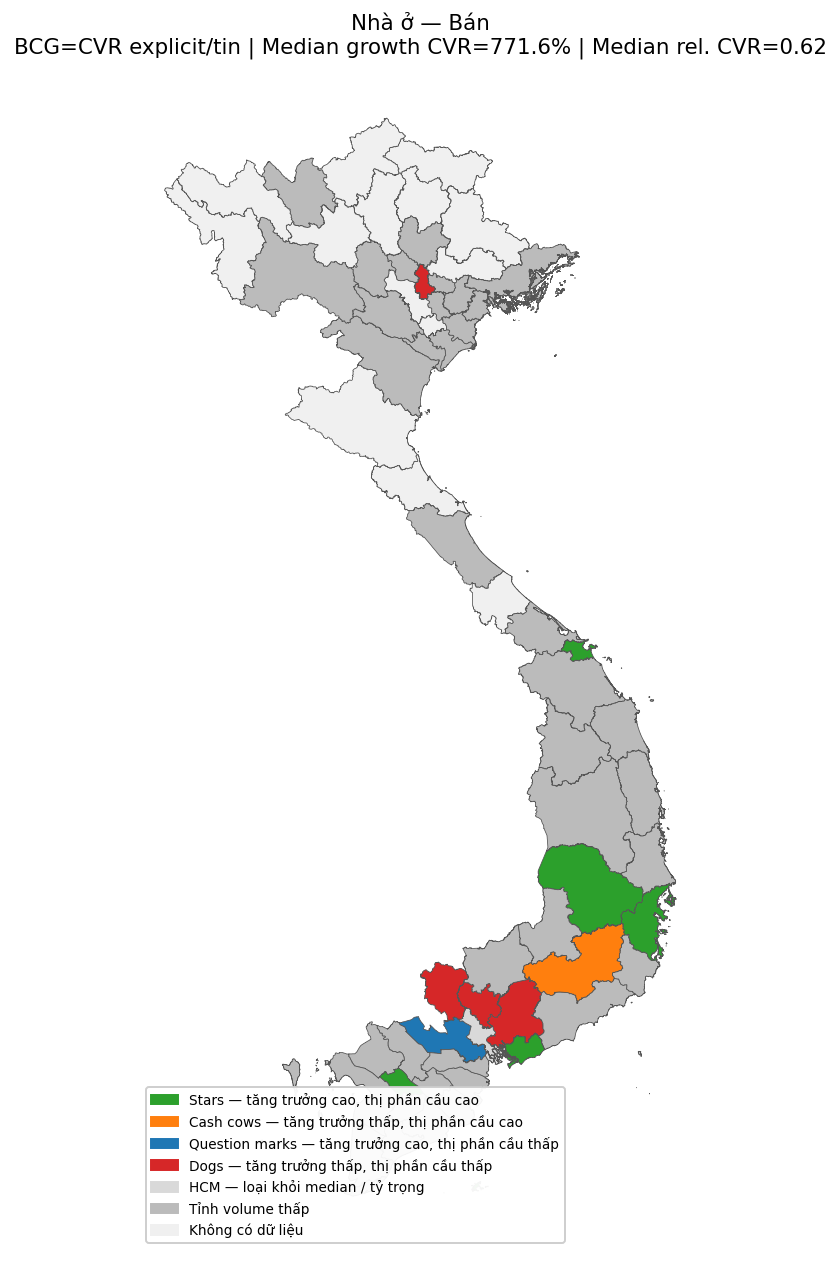

### VP/MB — Thuê

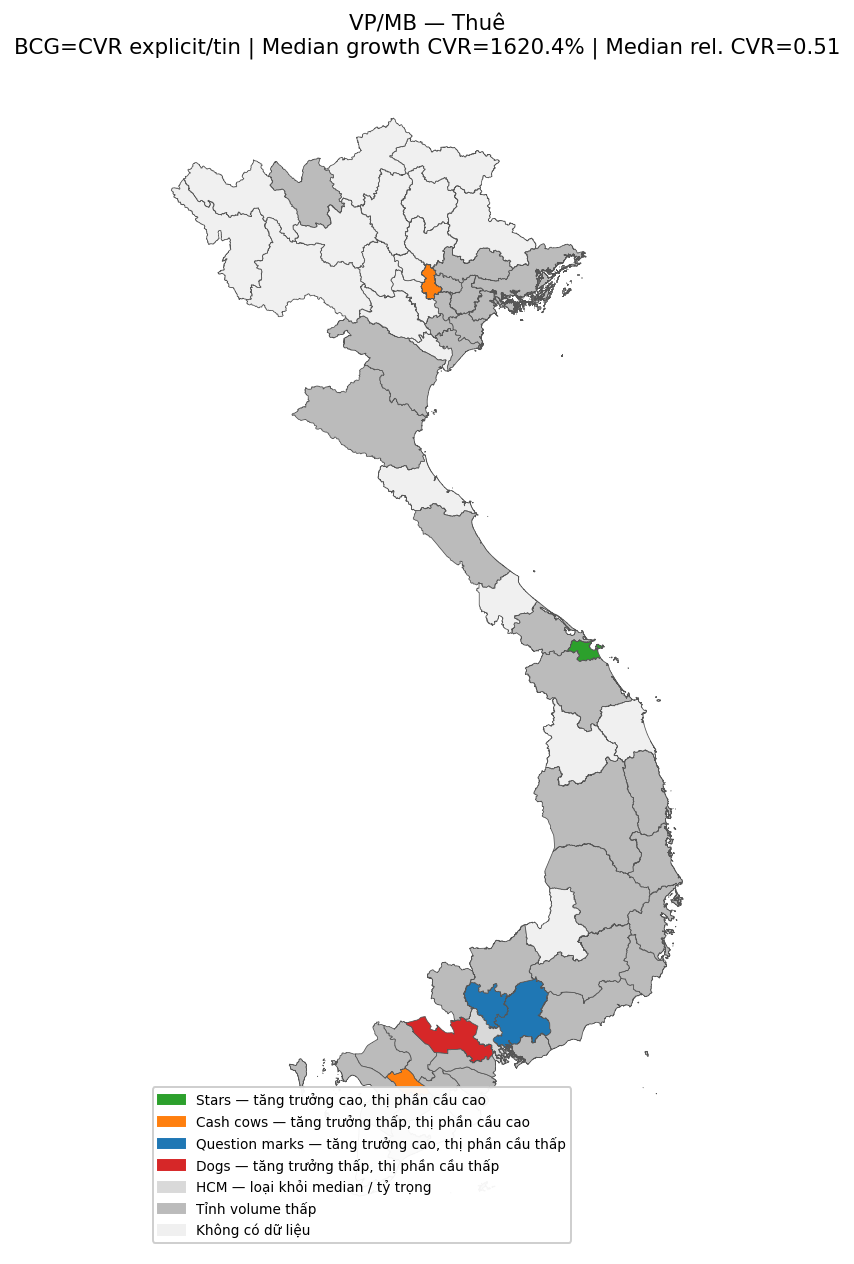

### VP/MB — Bán

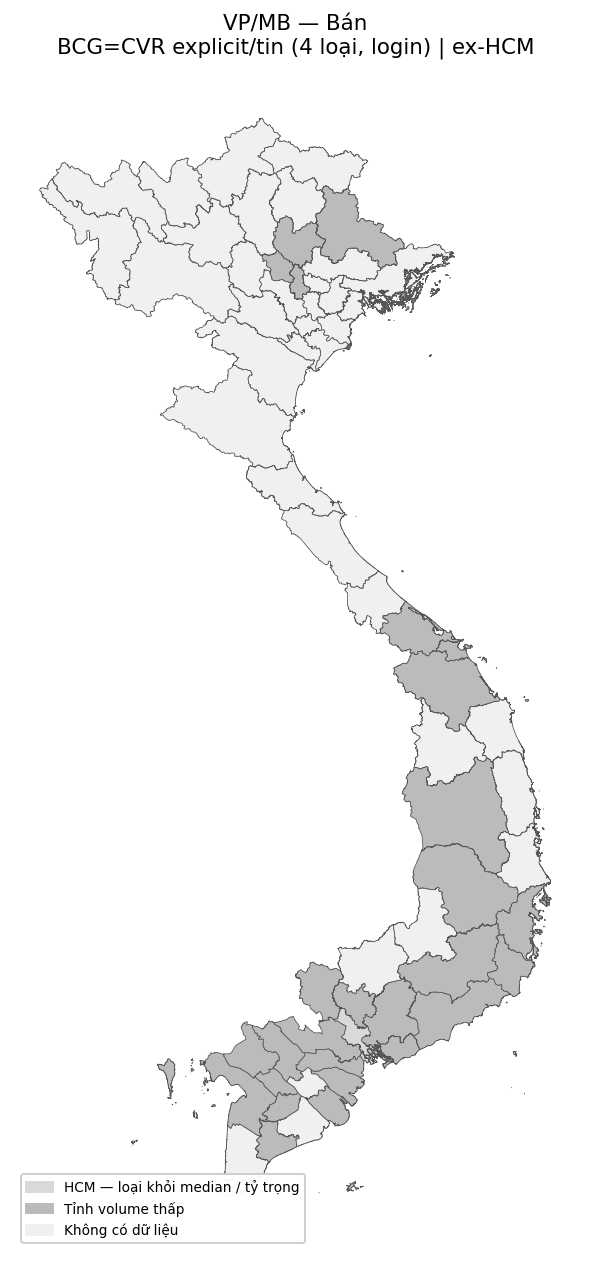

### Đất — Thuê

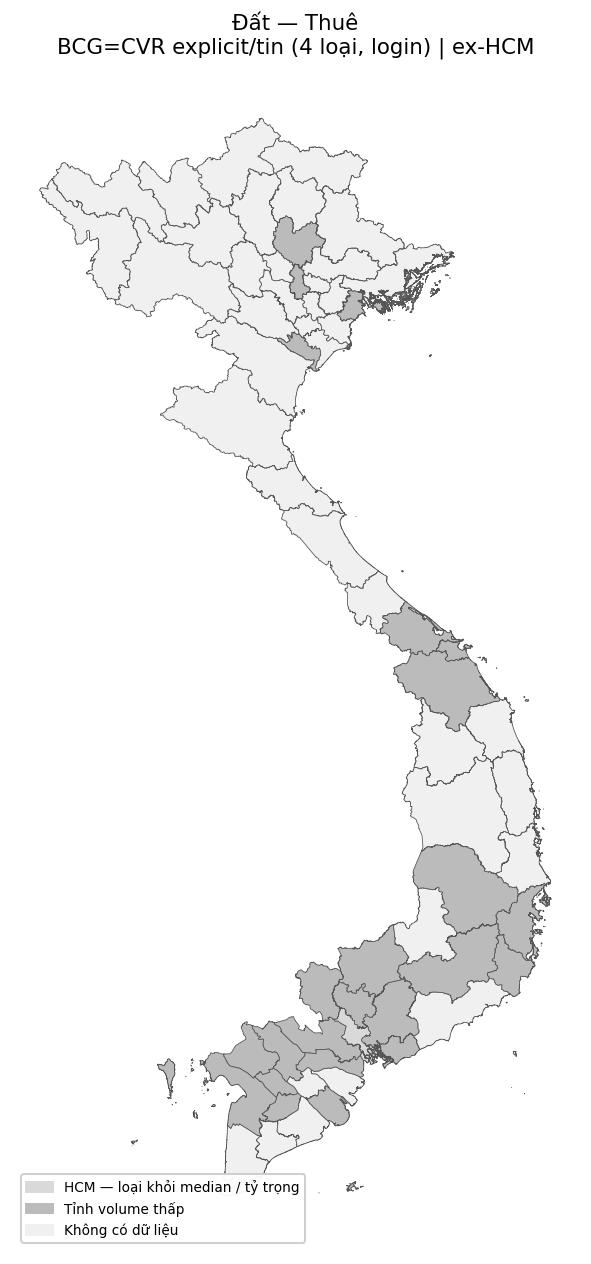

### Đất — Bán

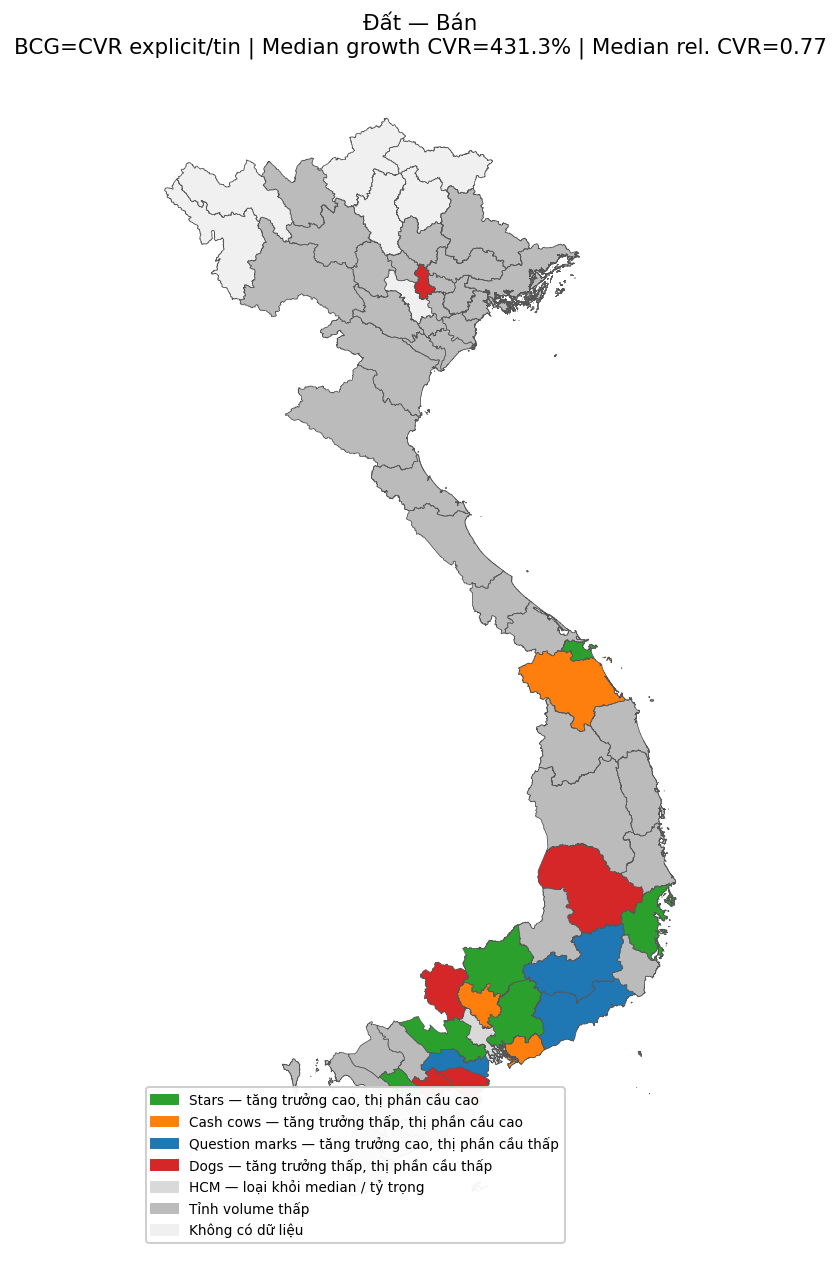

### Phòng trọ — Thuê

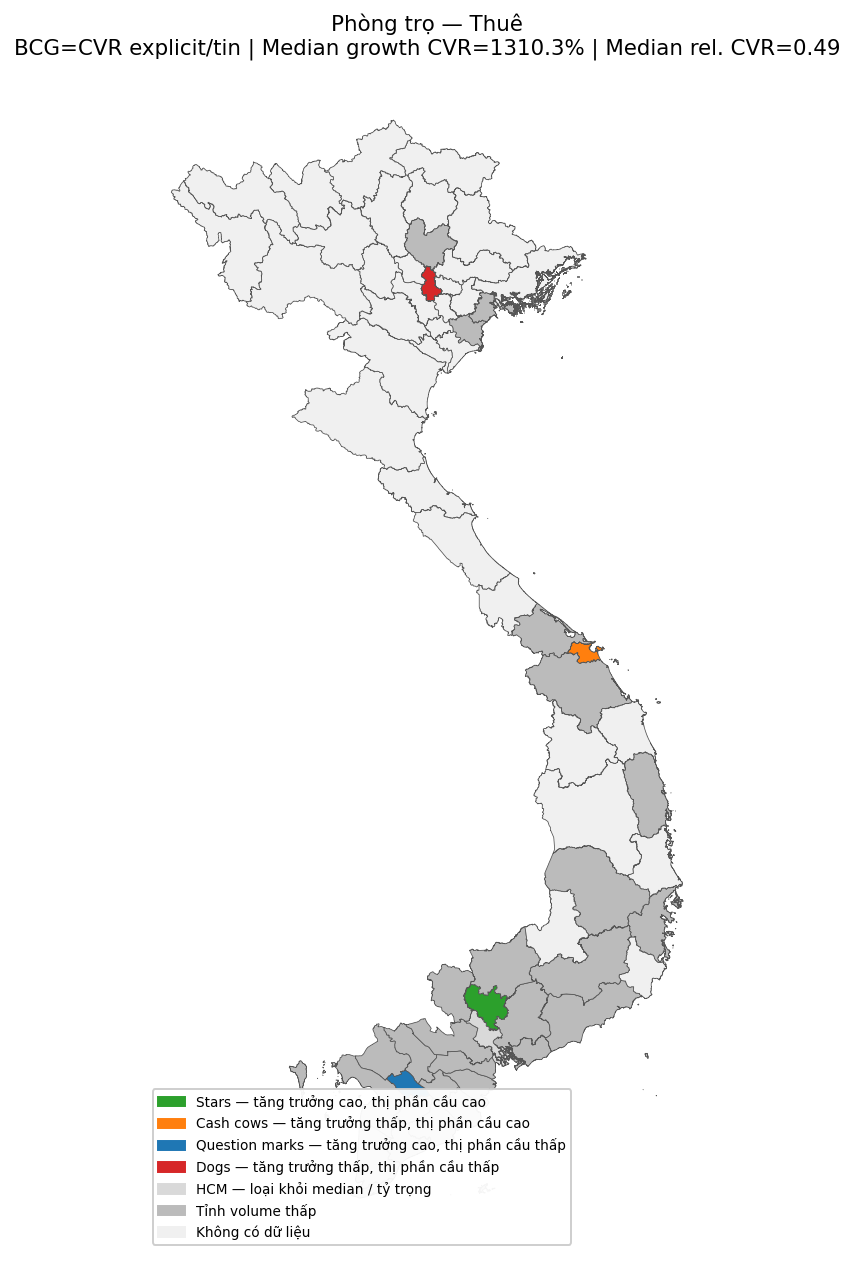

### Phòng trọ — Bán

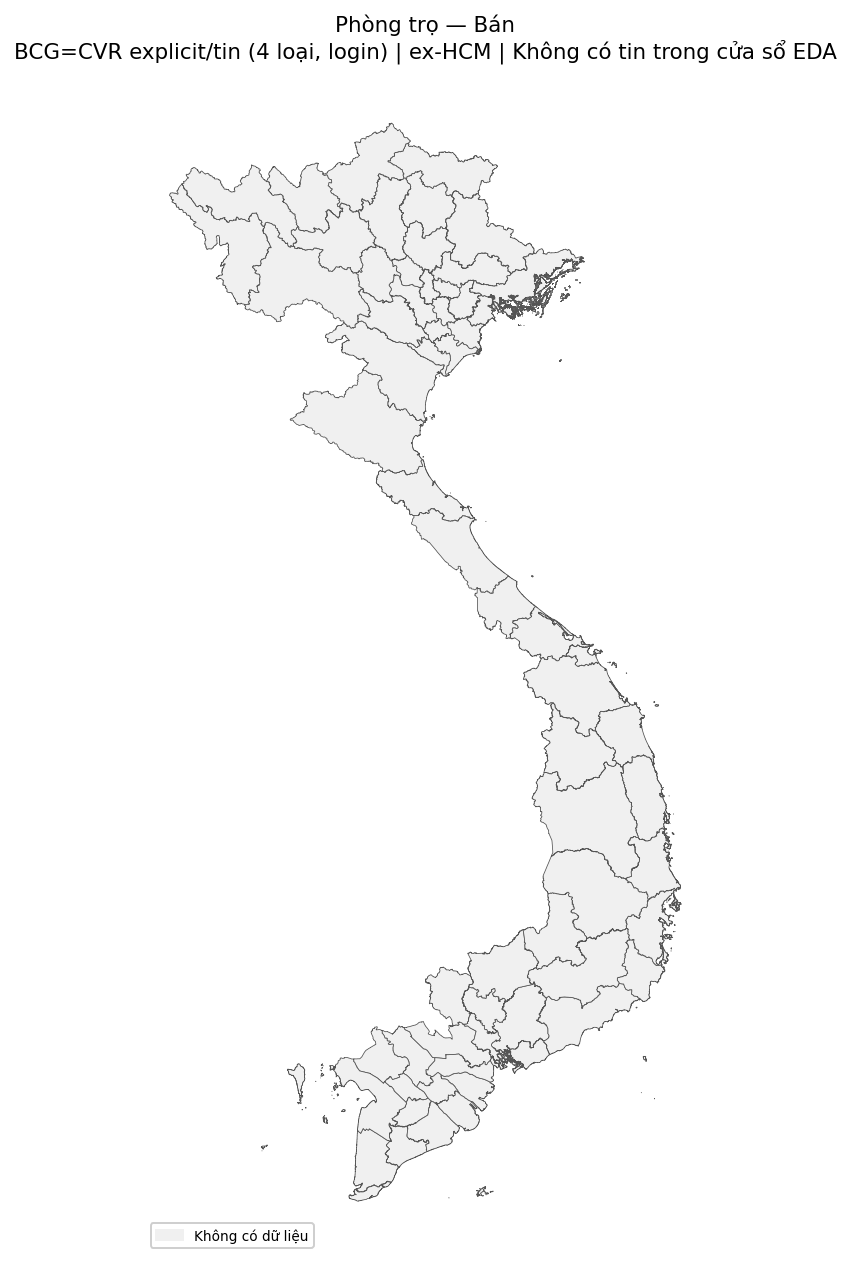

### Ma trận BCG — tỉnh × danh mục (L=Thuê, S=Bán, % cầu)

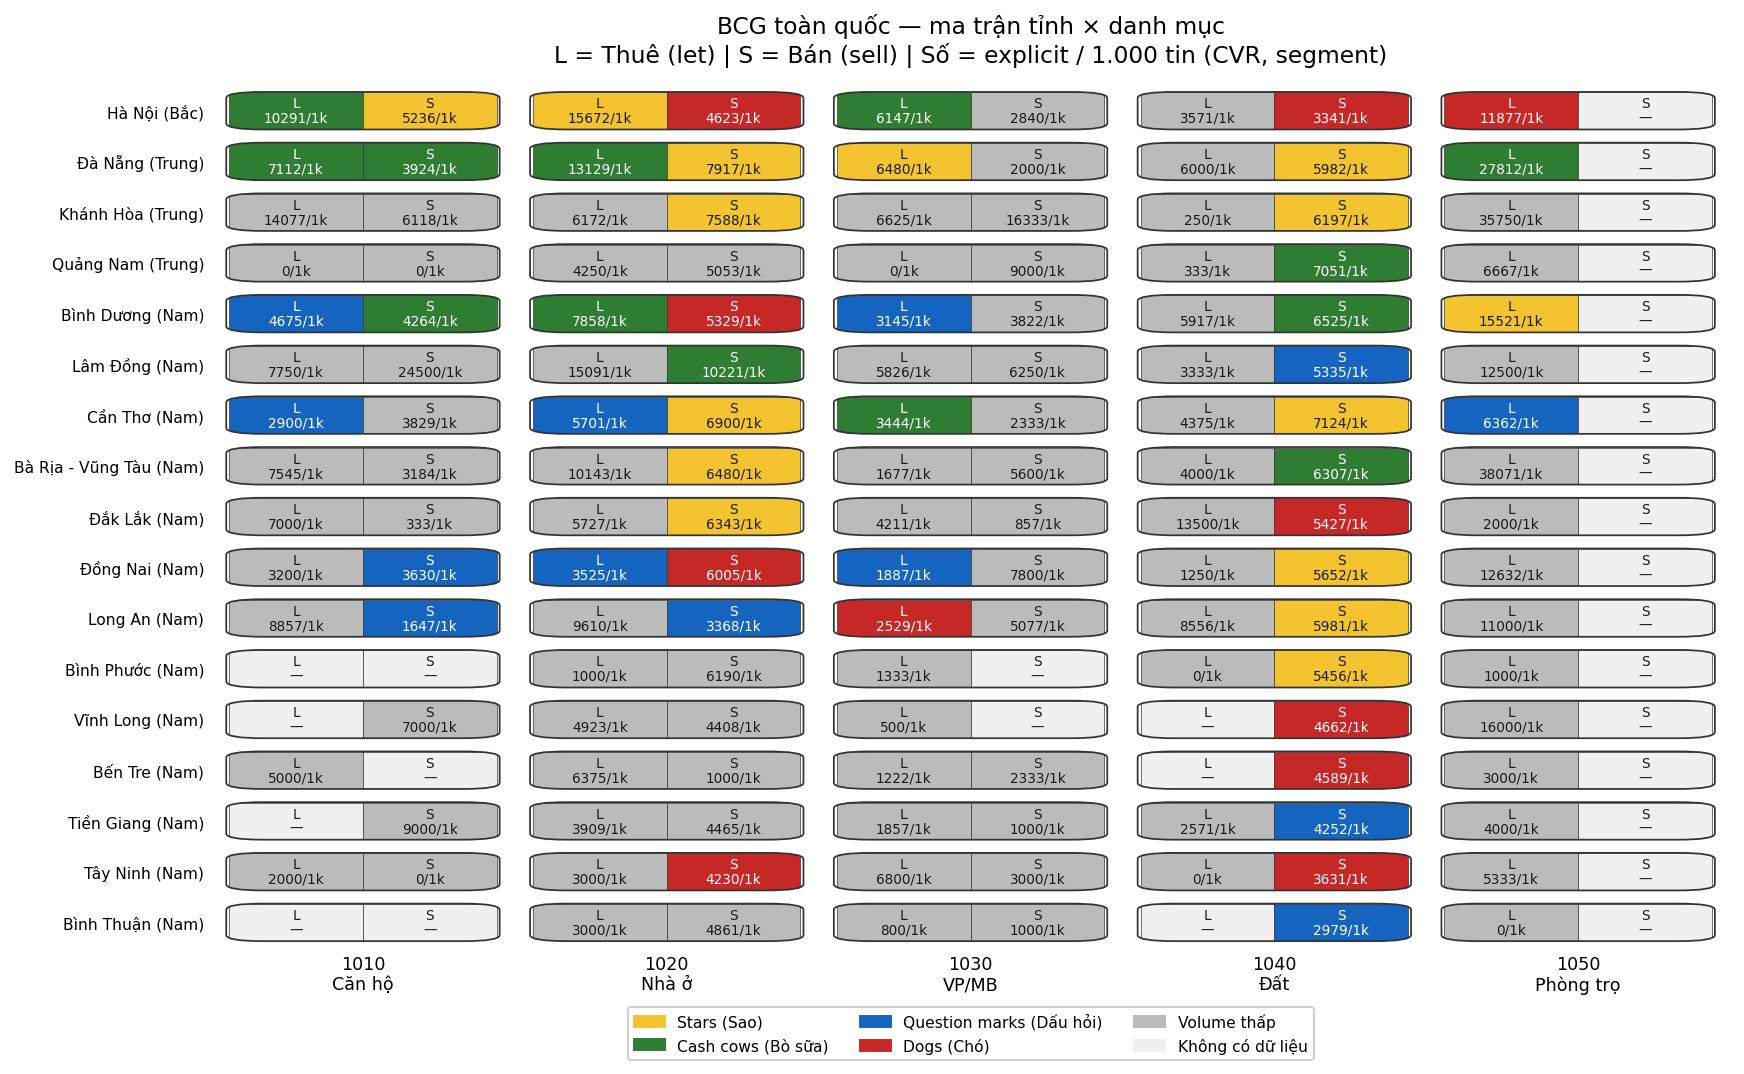

### Bảng wide (pill matrix)

,city_name,region,1010_let_quadrant,1010_let_cvr_per_1k,1010_sell_quadrant,1010_sell_cvr_per_1k,1020_let_quadrant,1020_let_cvr_per_1k,1020_sell_quadrant,1020_sell_cvr_per_1k,...,1030_sell_quadrant,1030_sell_cvr_per_1k,1040_let_quadrant,1040_let_cvr_per_1k,1040_sell_quadrant,1040_sell_cvr_per_1k,1050_let_quadrant,1050_let_cvr_per_1k,1050_sell_quadrant,1050_sell_cvr_per_1k
0,Hà Nội,Bac,cash_cows,10291.208791,stars,5235.549133,stars,15672.297297,dogs,4622.516556,...,low_volume,2840.000000,low_volume,3571.428571,dogs,3341.246291,dogs,11876.543210,none,NaN
1,Đà Nẵng,Trung,cash_cows,7112.149533,cash_cows,3924.342105,cash_cows,13129.251701,stars,7917.441860,...,low_volume,2000.000000,low_volume,6000.000000,stars,5982.120051,cash_cows,27812.500000,none,NaN
2,Khánh Hòa,Trung,low_volume,14076.923077,low_volume,6117.647059,low_volume,6172.413793,stars,7588.235294,...,low_volume,16333.333333,low_volume,250.000000,stars,6197.368421,low_volume,35750.000000,none,NaN
3,Quảng Nam,Trung,low_volume,0.000000,low_volume,0.000000,low_volume,4250.000000,low_volume,5052.631579,...,low_volume,9000.000000,low_volume,333.333333,cash_cows,7050.955414,low_volume,6666.666667,none,NaN
4,Bình Dương,Nam,question_marks,4674.576271,cash_cows,4264.478764,cash_cows,7858.208955,dogs,5329.004329,...,low_volume,3822.222222,low_volume,5916.666667,cash_cows,6524.752475,stars,15521.126761,none,NaN
5,Lâm Đồng,Nam,low_volume,7750.000000,low_volume,24500.000000,low_volume,15090.909091,cash_cows,10220.588235,...,low_volume,6250.000000,low_volume,3333.333333,question_marks,5335.051546,low_volume,12500.000000,none,NaN
6,Cần Thơ,Nam,question_marks,2900.000000,low_volume,3829.268293,question_marks,5700.854701,stars,6899.543379,...,low_volume,2333.333333,low_volume,4375.000000,stars,7124.137931,question_marks,6362.068966,none,NaN
7,Bà Rịa - Vũng Tàu,Nam,low_volume,7545.454545,low_volume,3184.210526,low_volume,10142.857143,stars,6480.314961,...,low_volume,5600.000000,low_volume,4000.000000,cash_cows,6307.042254,low_volume,38071.428571,none,NaN
8,Đắk Lắk,Nam,low_volume,7000.000000,low_volume,333.333333,low_volume,5727.272727,stars,6343.434343,...,low_volume,857.142857,low_volume,13500.000000,dogs,5427.135678,low_volume,2000.000000,none,NaN
9,Đồng Nai,Nam,low_volume,3200.000000,question_marks,3629.629630,question_marks,3524.752475,dogs,6004.914005,...,low_volume,7800.000000,low_volume,1250.000000,stars,5651.655629,low_volume,12631.578947,none,NaN


In [20]:
from IPython.display import Image, Markdown, display

MAP = OUT / "maps"
bcg_csv = OUT / "06_bcg_national_choropleth.csv"
if bcg_csv.exists():
    bcg_nat = pd.read_csv(bcg_csv)
    display(Markdown("### Phân bố BCG CVR (toàn quốc, ex-HCM median)"))
    display(
        bcg_nat[bcg_nat.bcg_quadrant != "hcmc_excluded"]
        .groupby(["category", "ad_type", "bcg_quadrant"])
        .size()
        .unstack(fill_value=0)
    )

for cat in (1010, 1020, 1030, 1040, 1050):
    for adt in ("let", "sell"):
        p = MAP / f"fig_bcg_choropleth_{cat}_{adt}.png"
        if p.exists():
            label = mod.CAT_META.get(cat, str(cat))
            display(Markdown(f"### {label} — {'Thuê' if adt == 'let' else 'Bán'}"))
            display(Image(filename=str(p)))

pill_png = MAP / "fig_bcg_pill_matrix.png"
pill_csv = OUT / "07_bcg_pill_matrix_wide.csv"
meth = OUT / "08_bcg_pill_matrix_methodology.txt"
if meth.exists():
    display(Markdown("### Công thức pill matrix"))
    display(Markdown(meth.read_text(encoding="utf-8")))
if pill_png.exists():
    display(Markdown("### Ma trận BCG — tỉnh × danh mục (L/S, CVR/tin, n mẫu)"))
    display(Image(filename=str(pill_png)))
if pill_csv.exists():
    display(Markdown("### Bảng wide (pill matrix, kèm `*_n_listings`)"))
    display(pd.read_csv(pill_csv))

## §6 — Playbook 4 nhóm BCG & Action Matrix (v2)

| Output | Mô tả |
|--------|--------|
| `BCG_QUADRANT_PLAYBOOK.md` | Chiến lược Stars / Cows / QM / Dogs |
| `10_bcg_action_matrix.csv` | `priority_impact`, `priority_defend`, `borderline_flag`, `listing_survival_rate` |
| `09_bcg_quadrant_profiles.csv` | Profile aggregate theo màu |
| `figs/fig_bcg_quadrant_summary.png` | 4 panel tổng quan |
| `figs/fig_bcg_priority_top20.png` | Top impact vs defend |

**Chạy:** `env/bin/python Thinh_Analyze/run_bcg_quadrant_playbook.py`  
**Deep dive (item survival + lever):** thêm `--init-db`

In [ ]:
from IPython.display import Image, Markdown, display

FIGS = OUT / "figs"
playbook_md = OUT / "BCG_QUADRANT_PLAYBOOK.md"
action_csv = OUT / "10_bcg_action_matrix.csv"
profiles_csv = OUT / "09_bcg_quadrant_profiles.csv"

if playbook_md.exists():
    display(Markdown("### Playbook"))
    display(Markdown(playbook_md.read_text(encoding="utf-8")[:8000]))

if profiles_csv.exists():
    display(Markdown("### Profile 4 nhóm"))
    display(pd.read_csv(profiles_csv))

if action_csv.exists():
    act = pd.read_csv(action_csv)
    display(Markdown("### Top priority_impact (khai thác)"))
    cols = [
        "city_name", "region", "category", "ad_type", "bcg_quadrant",
        "cvr_per_listing", "growth_cvr_pct", "n_listings", "n_explicit_events",
        "priority_impact", "priority_defend", "borderline_flag", "listing_survival_rate",
        "bcg_median_scope", "scenario_to_median", "peer_top3",
    ]
    display(act.nlargest(15, "priority_impact")[[c for c in cols if c in act.columns]])
    display(Markdown("### Top priority_defend (Stars/Cows suy growth)"))
    display(
        act[act["priority_defend"] > 0]
        .nlargest(10, "priority_defend")[[c for c in cols if c in act.columns]]
    )

for fig_name in ("fig_bcg_quadrant_summary.png", "fig_bcg_priority_top20.png"):
    p = FIGS / fig_name
    if p.exists():
        display(Markdown(f"### {fig_name}"))
        display(Image(filename=str(p)))

## §3 — BCG quadrants

In [21]:
bcg = pd.read_csv(OUT / "05_bcg_quadrants.csv")
display(bcg[bcg.bcg_eligible].groupby(["region", "ad_type", "category", "bcg_quadrant"]).size().unstack(fill_value=0))
display(Markdown("### Stars — Nam / sell / 1020"))
display(bcg[(bcg.region == "Nam") & (bcg.ad_type == "sell") & (bcg.category == 1020) & (bcg.bcg_quadrant == "stars")][
    ["city_name", "relative_share", "growth_explicit_pct", "n_explicit_events"]
].sort_values("n_explicit_events", ascending=False))

bcg_quadrant             cash_cows  dogs  low_volume  question_marks  stars
region ad_type category                                                    
Bac    let     1010              0     0           1               0      0
               1020              0     0           1               0      0
               1030              0     0           1               0      0
               1050              0     0           1               0      0
       sell    1010              0     0           1               0      0
               1020              0     0           1               0      0
               1040              0     0           1               0      0
Nam    let     1010              1     0           0               1      0
               1020              1     0           0               1      1
               1030              1     1           0               1      1
               1050              0     1           0               0      1
       sell    1010              1     0           0               1      1
               1020              1     3           0               1      3
               1040              3     3           0               3      4
Trung  let     1010              0     0           1               0      0
               1020              0     0           1               0      0
               1030              0     0           1               0      0
               1040              0     0           1               0      0
               1050              0     0           1               0      0
       sell    1010              0     0           1               0      0
               1020              1     0           0               1      0
               1040              1     0           0               1      1

### Stars — Nam / sell / 1020

,city_name,relative_share,growth_explicit_pct,n_explicit_events
193,Cần Thơ,0.306864,1296.039604,1511
195,Bà Rịa - Vũng Tàu,0.167141,803.658537,823
197,Đắk Lắk,0.127539,4285.714286,628


## §4 — Ma trận BCG (6 chart)

### Bac × let

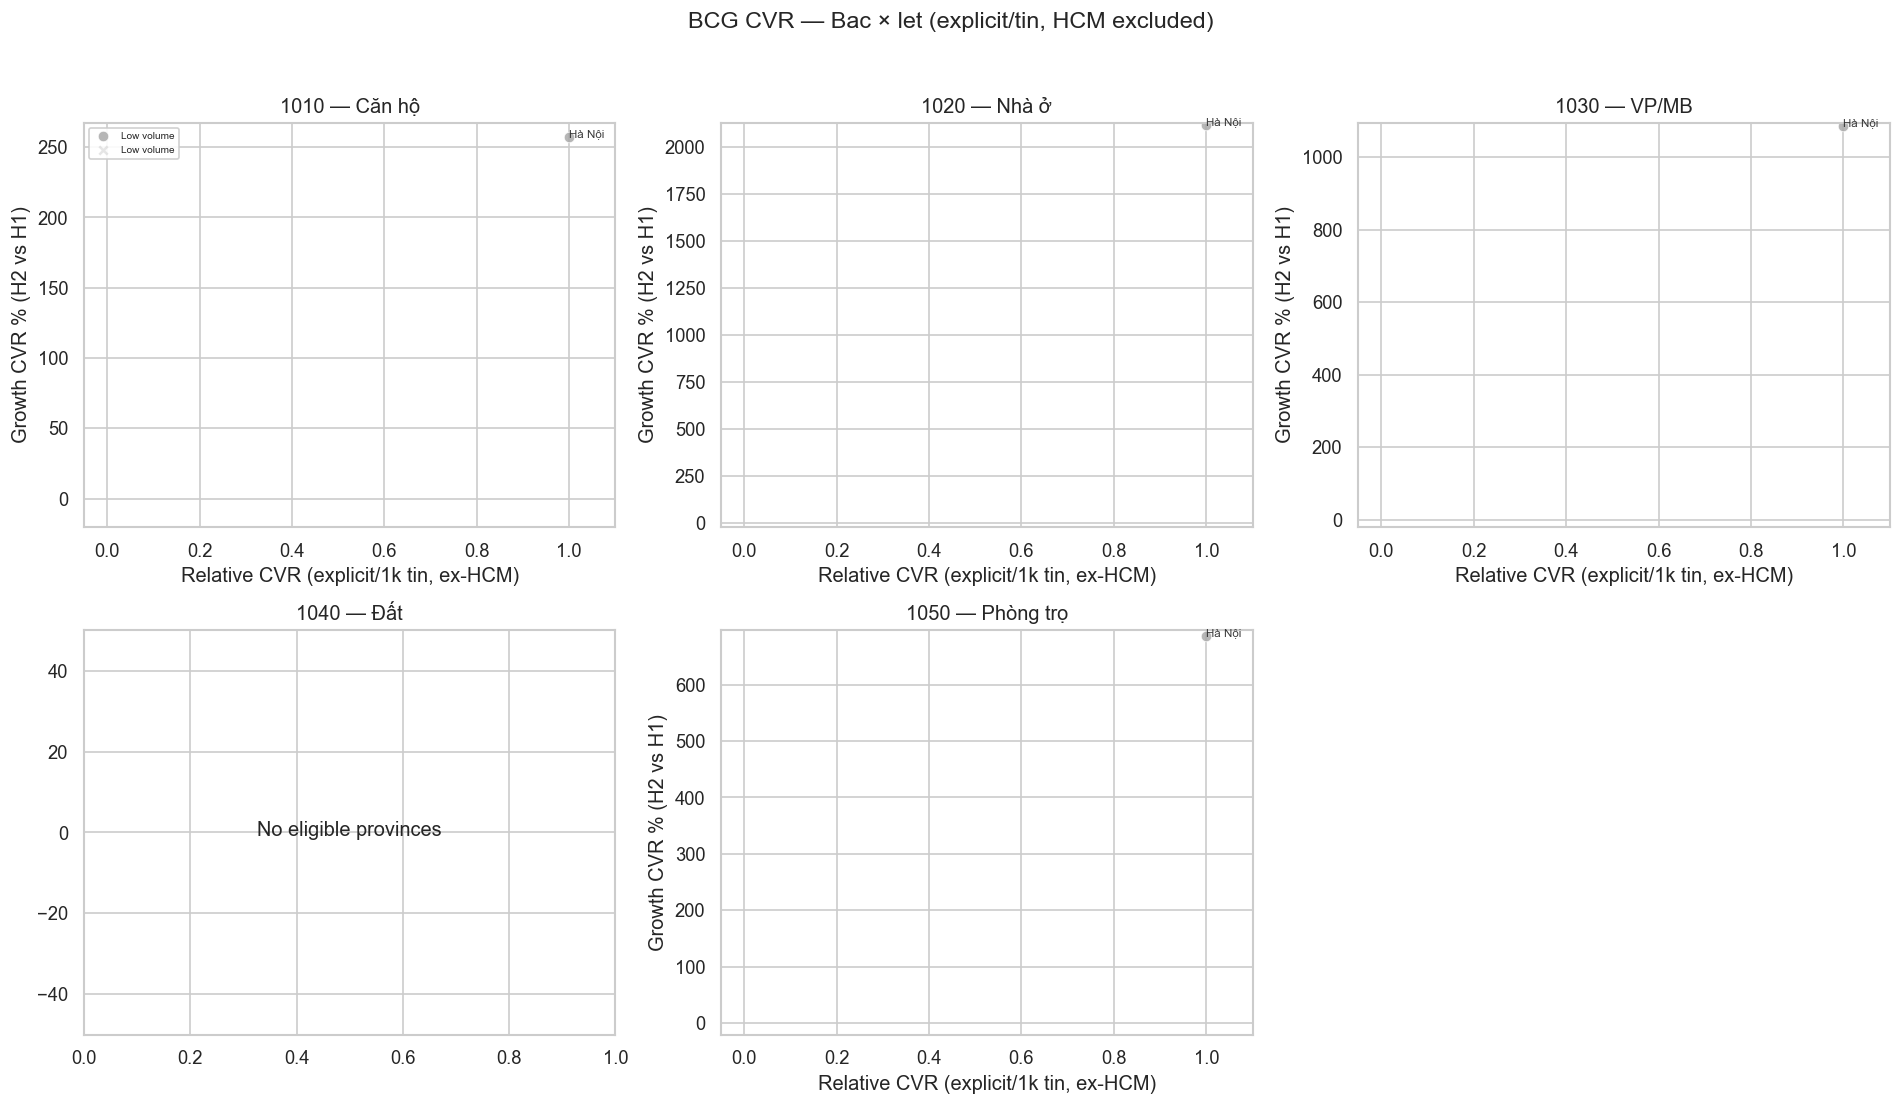

### Bac × sell

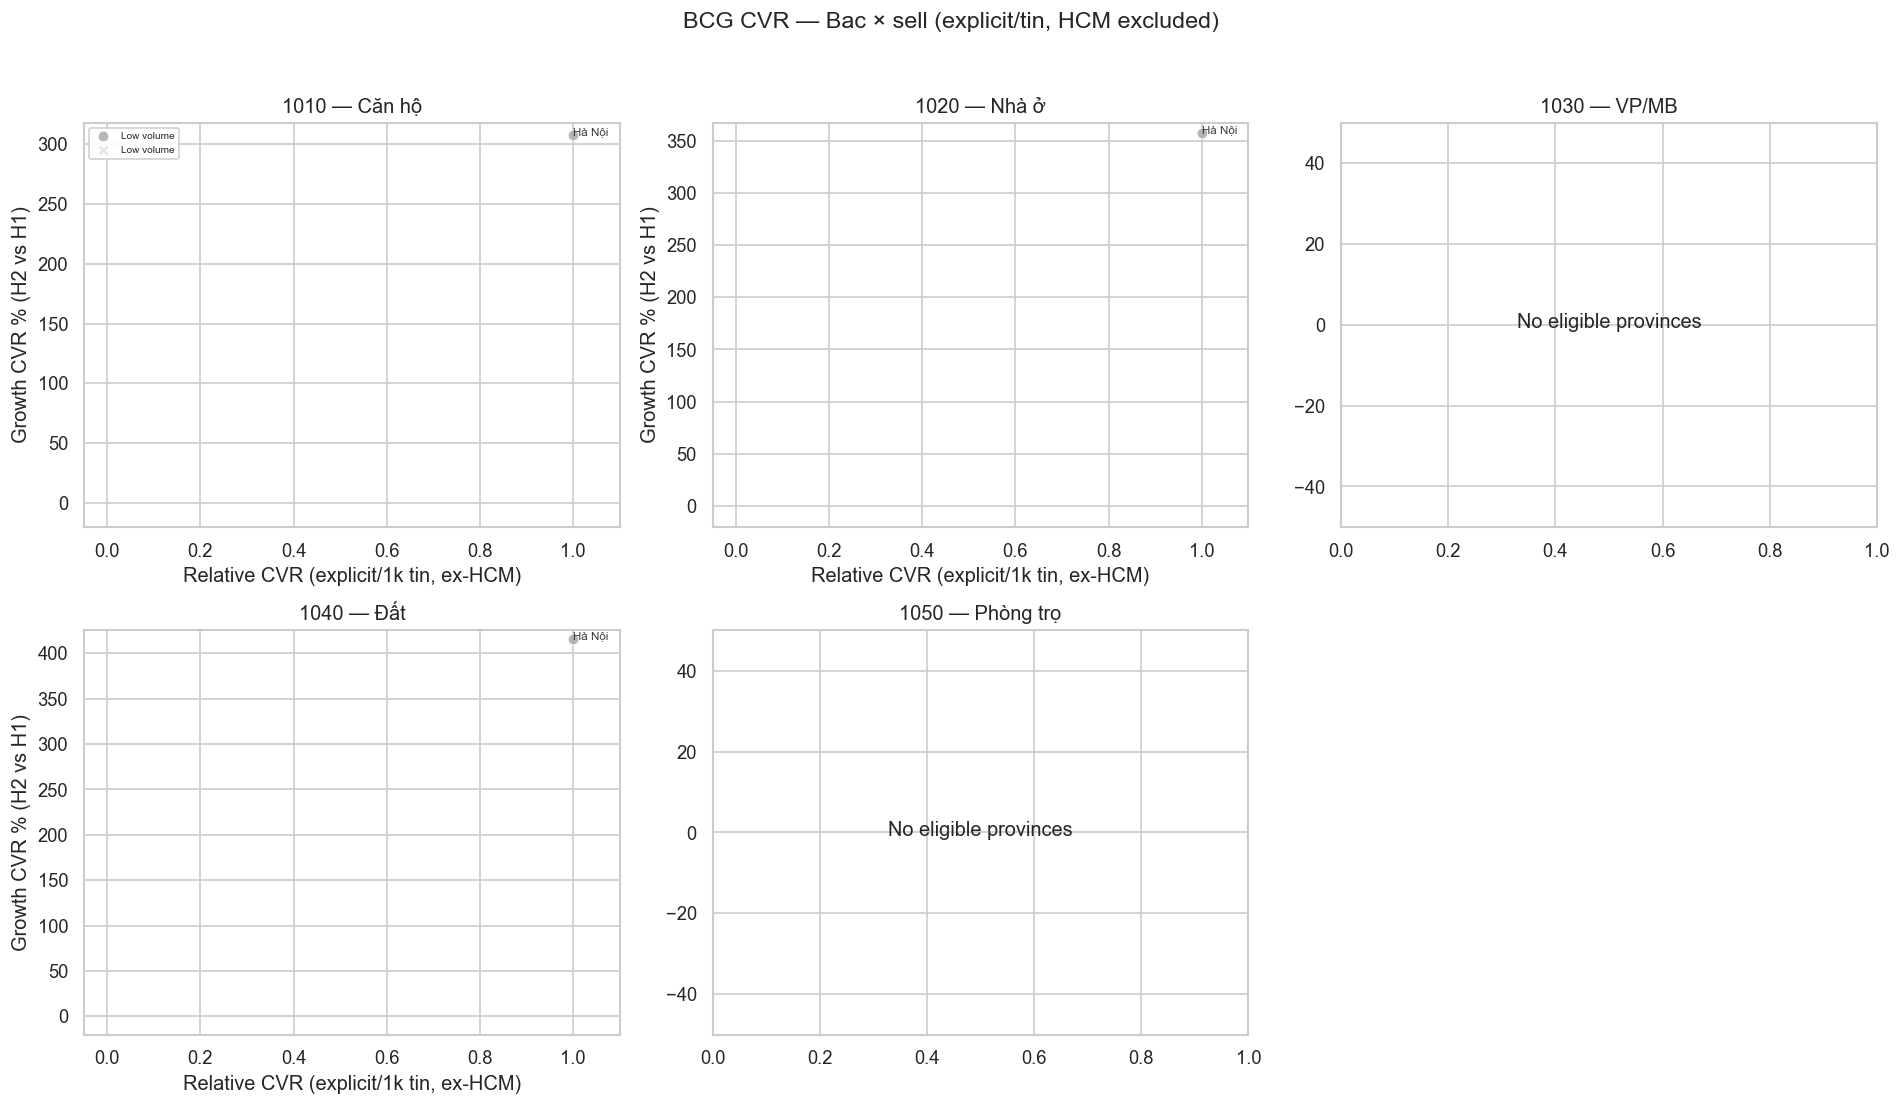

### Trung × let

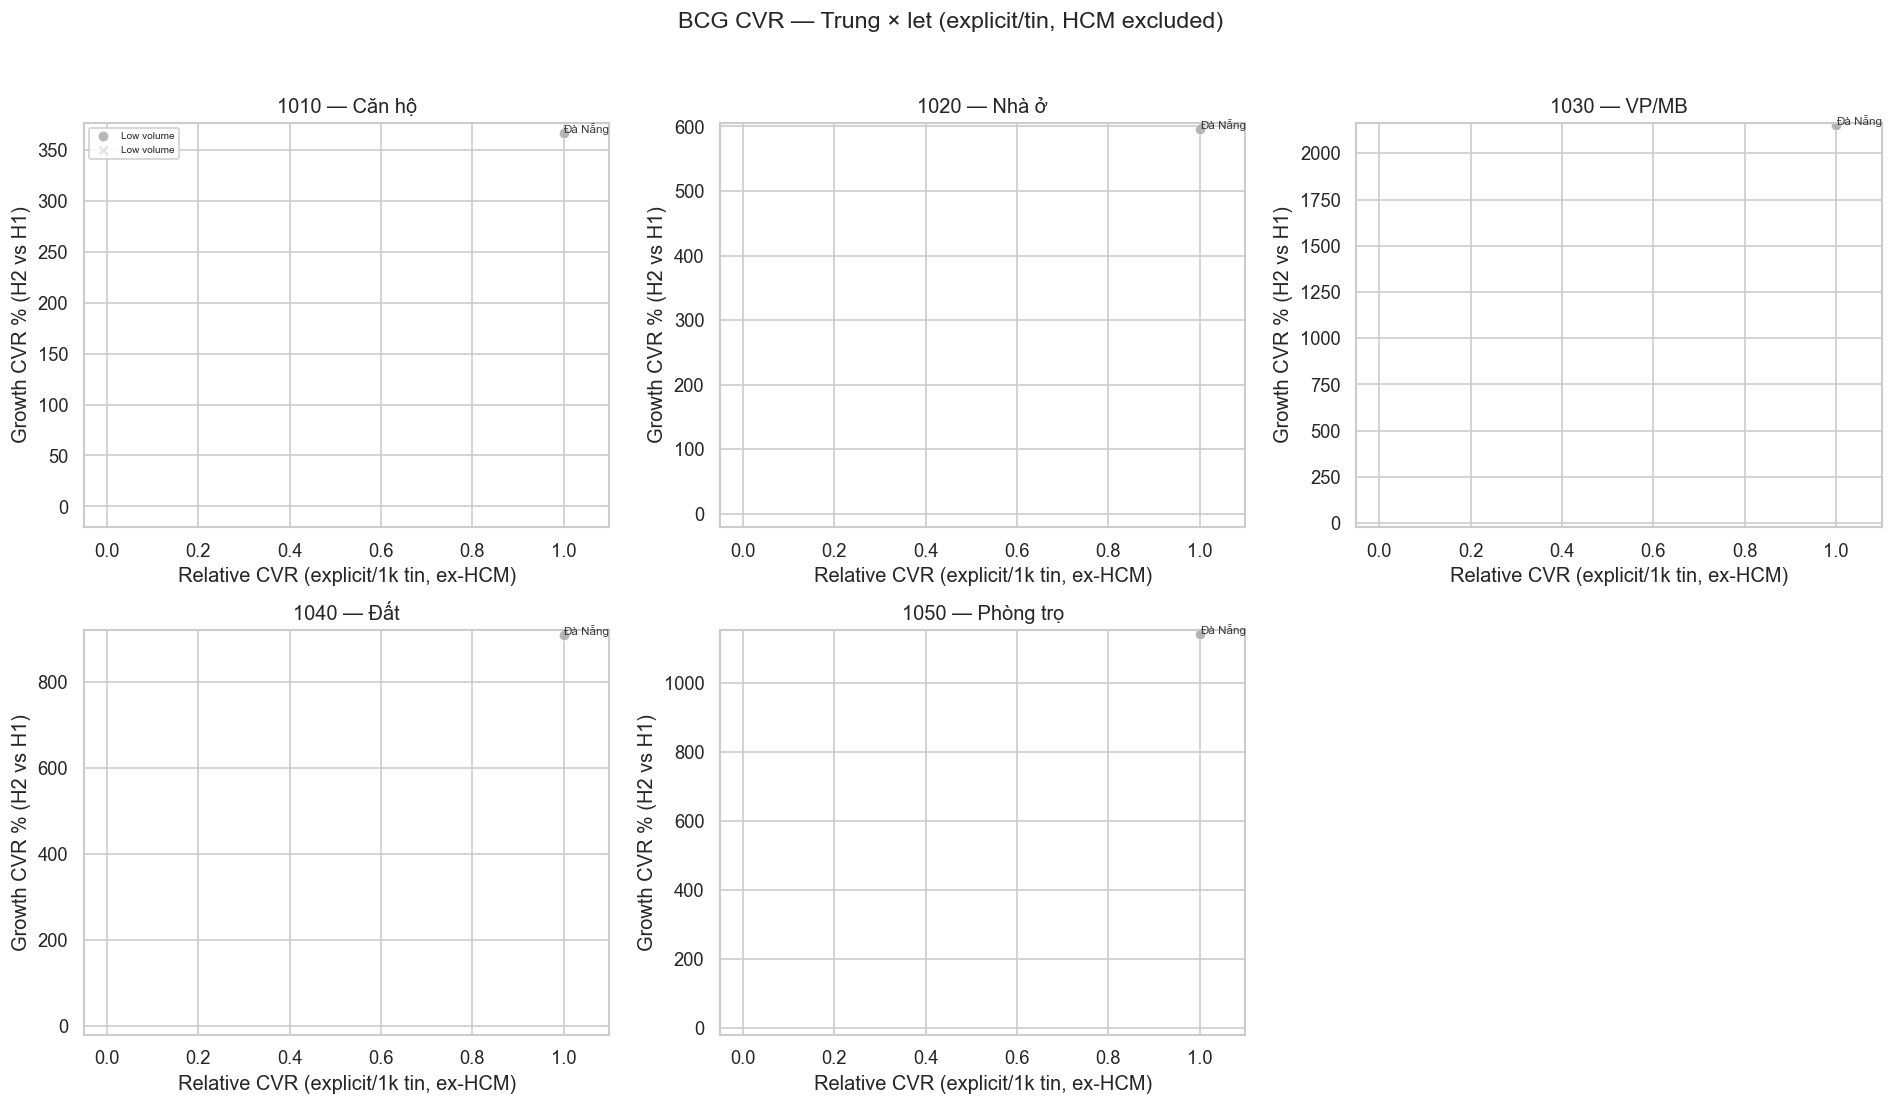

### Trung × sell

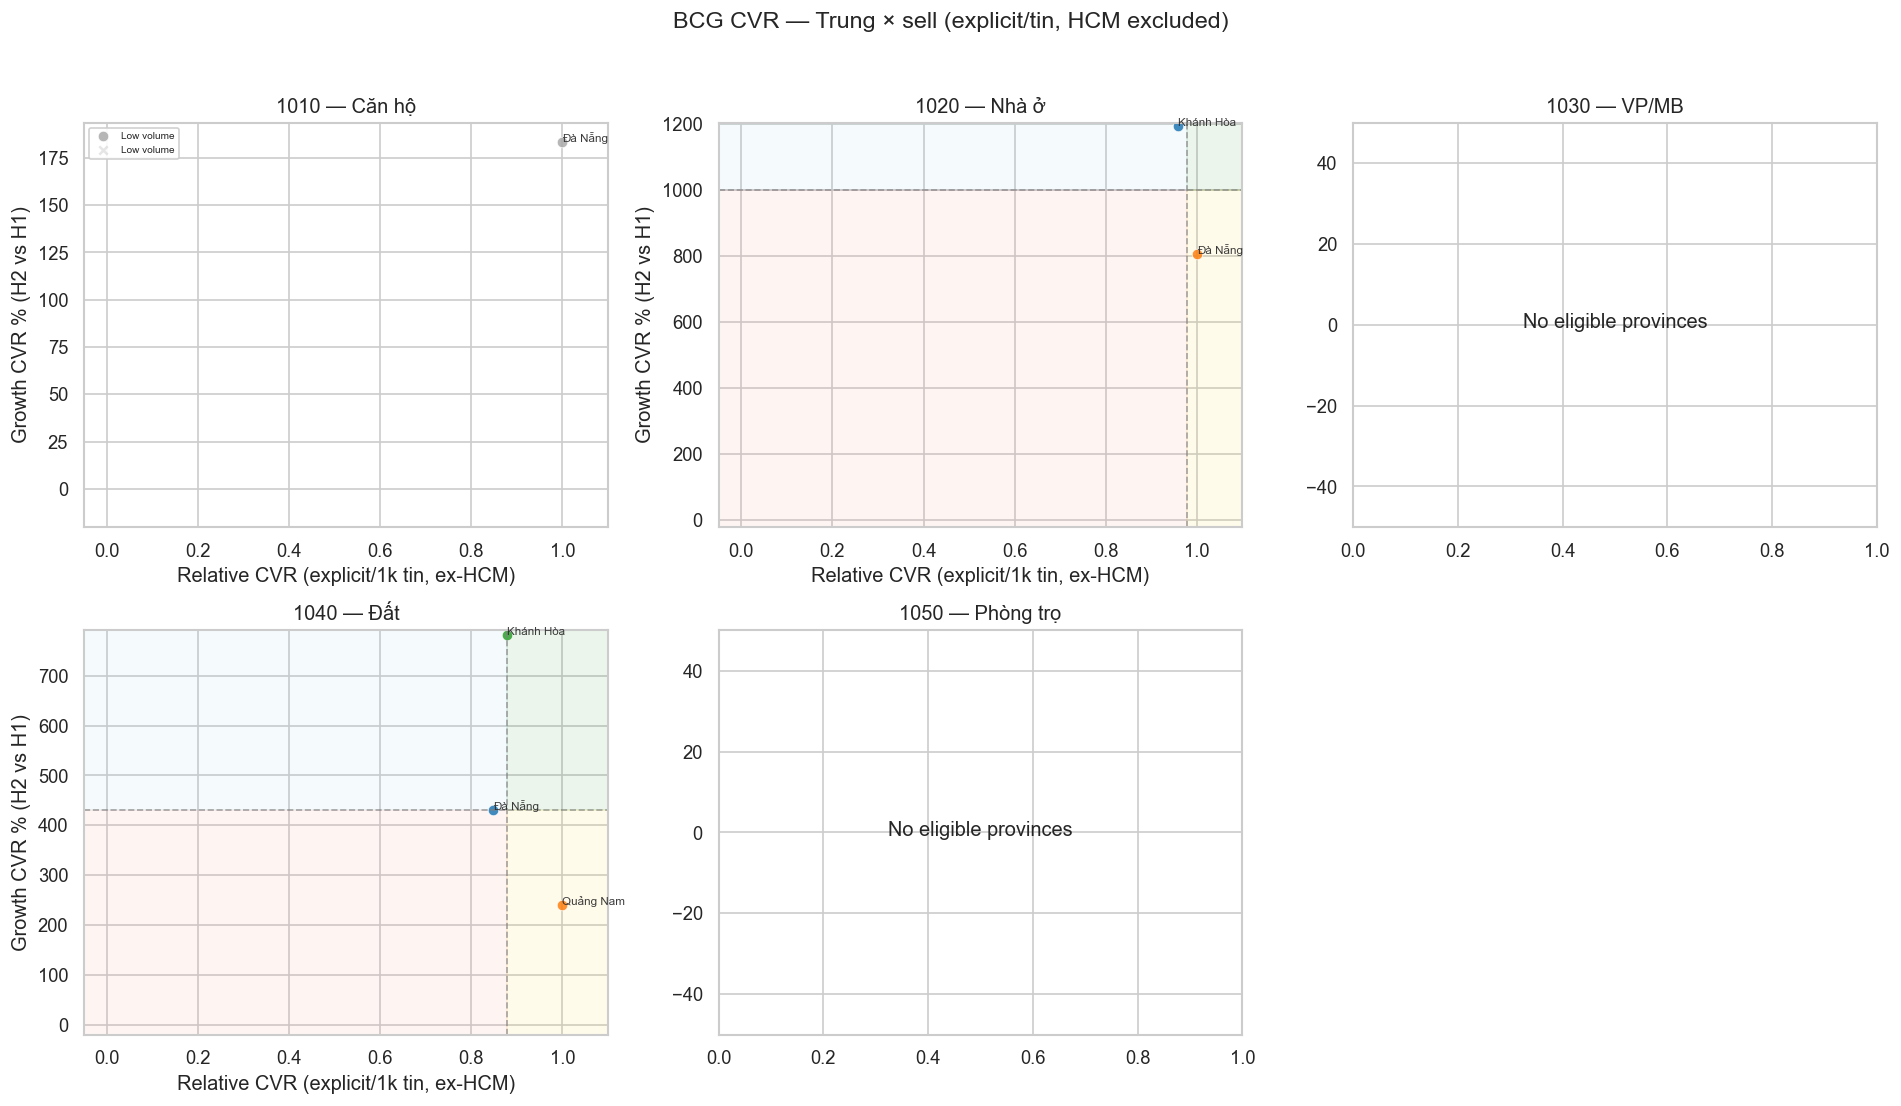

### Nam × let

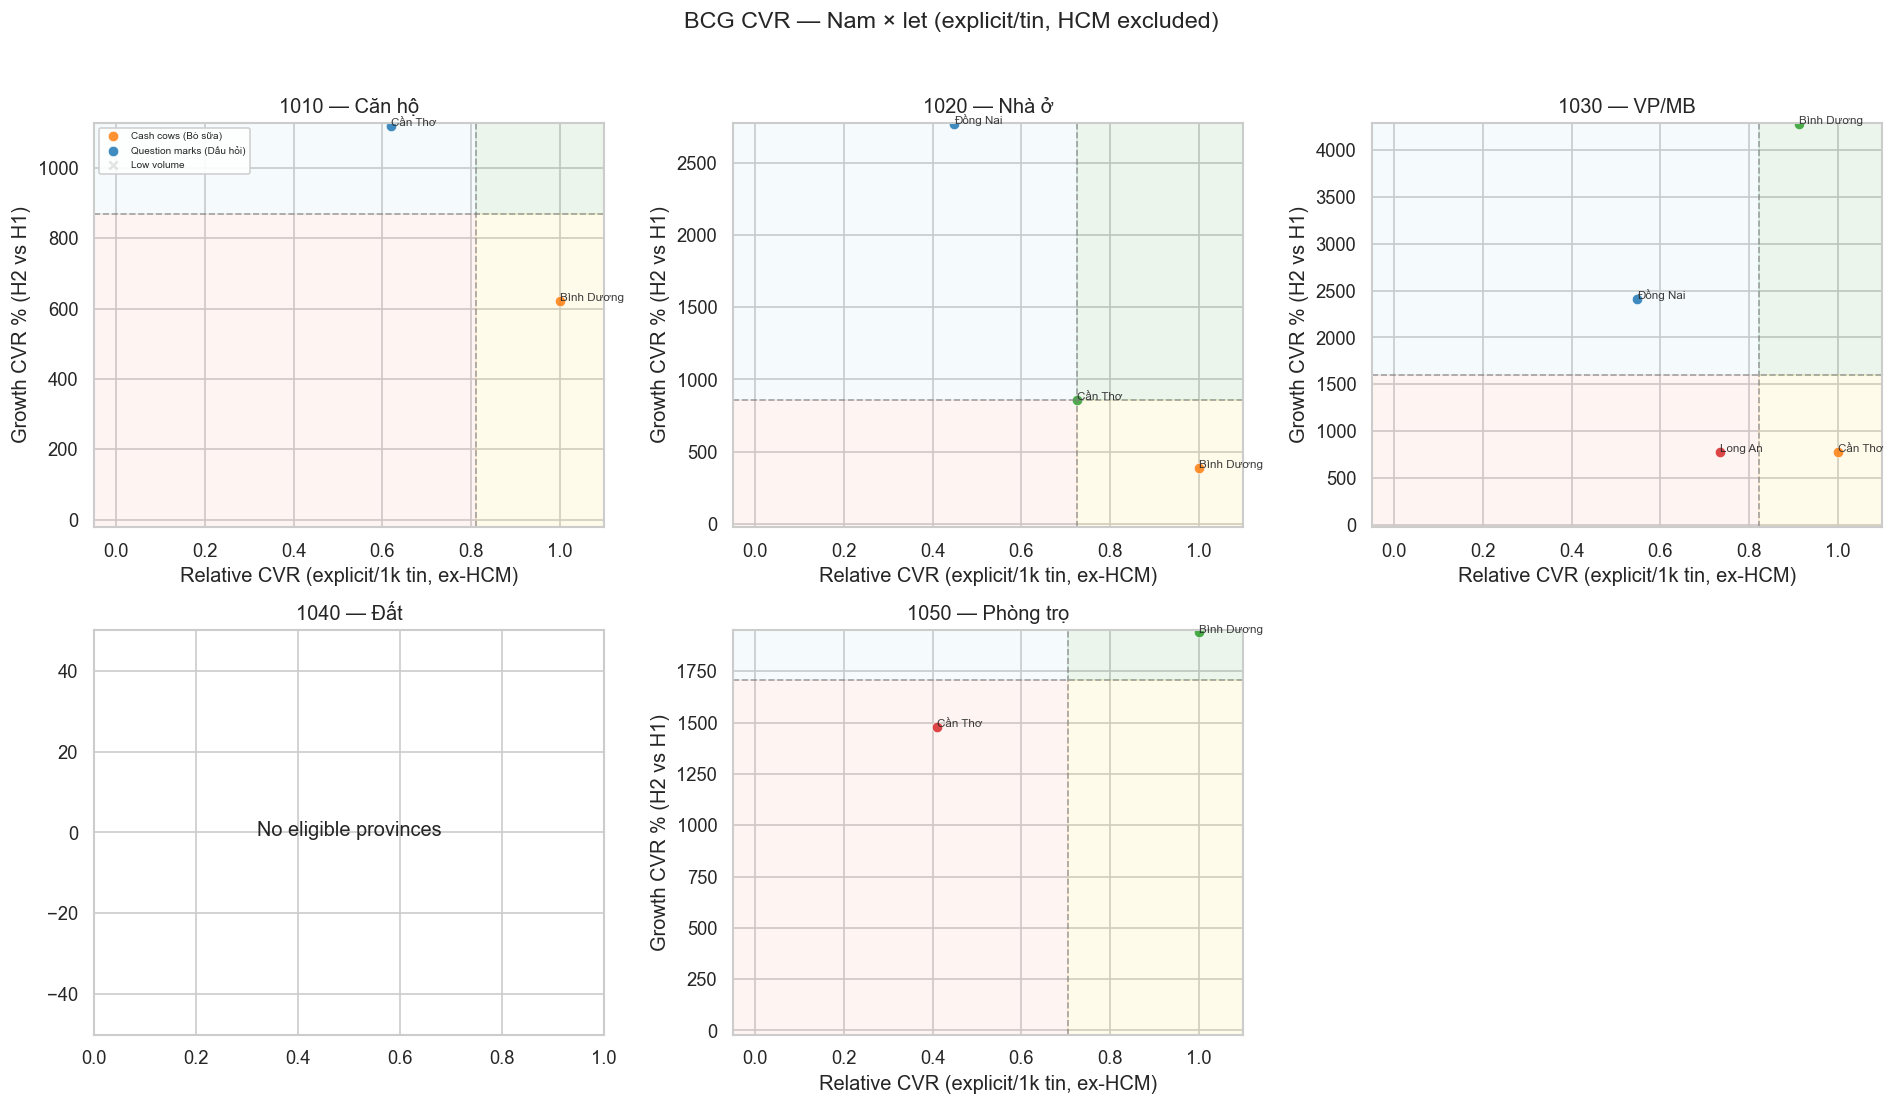

### Nam × sell

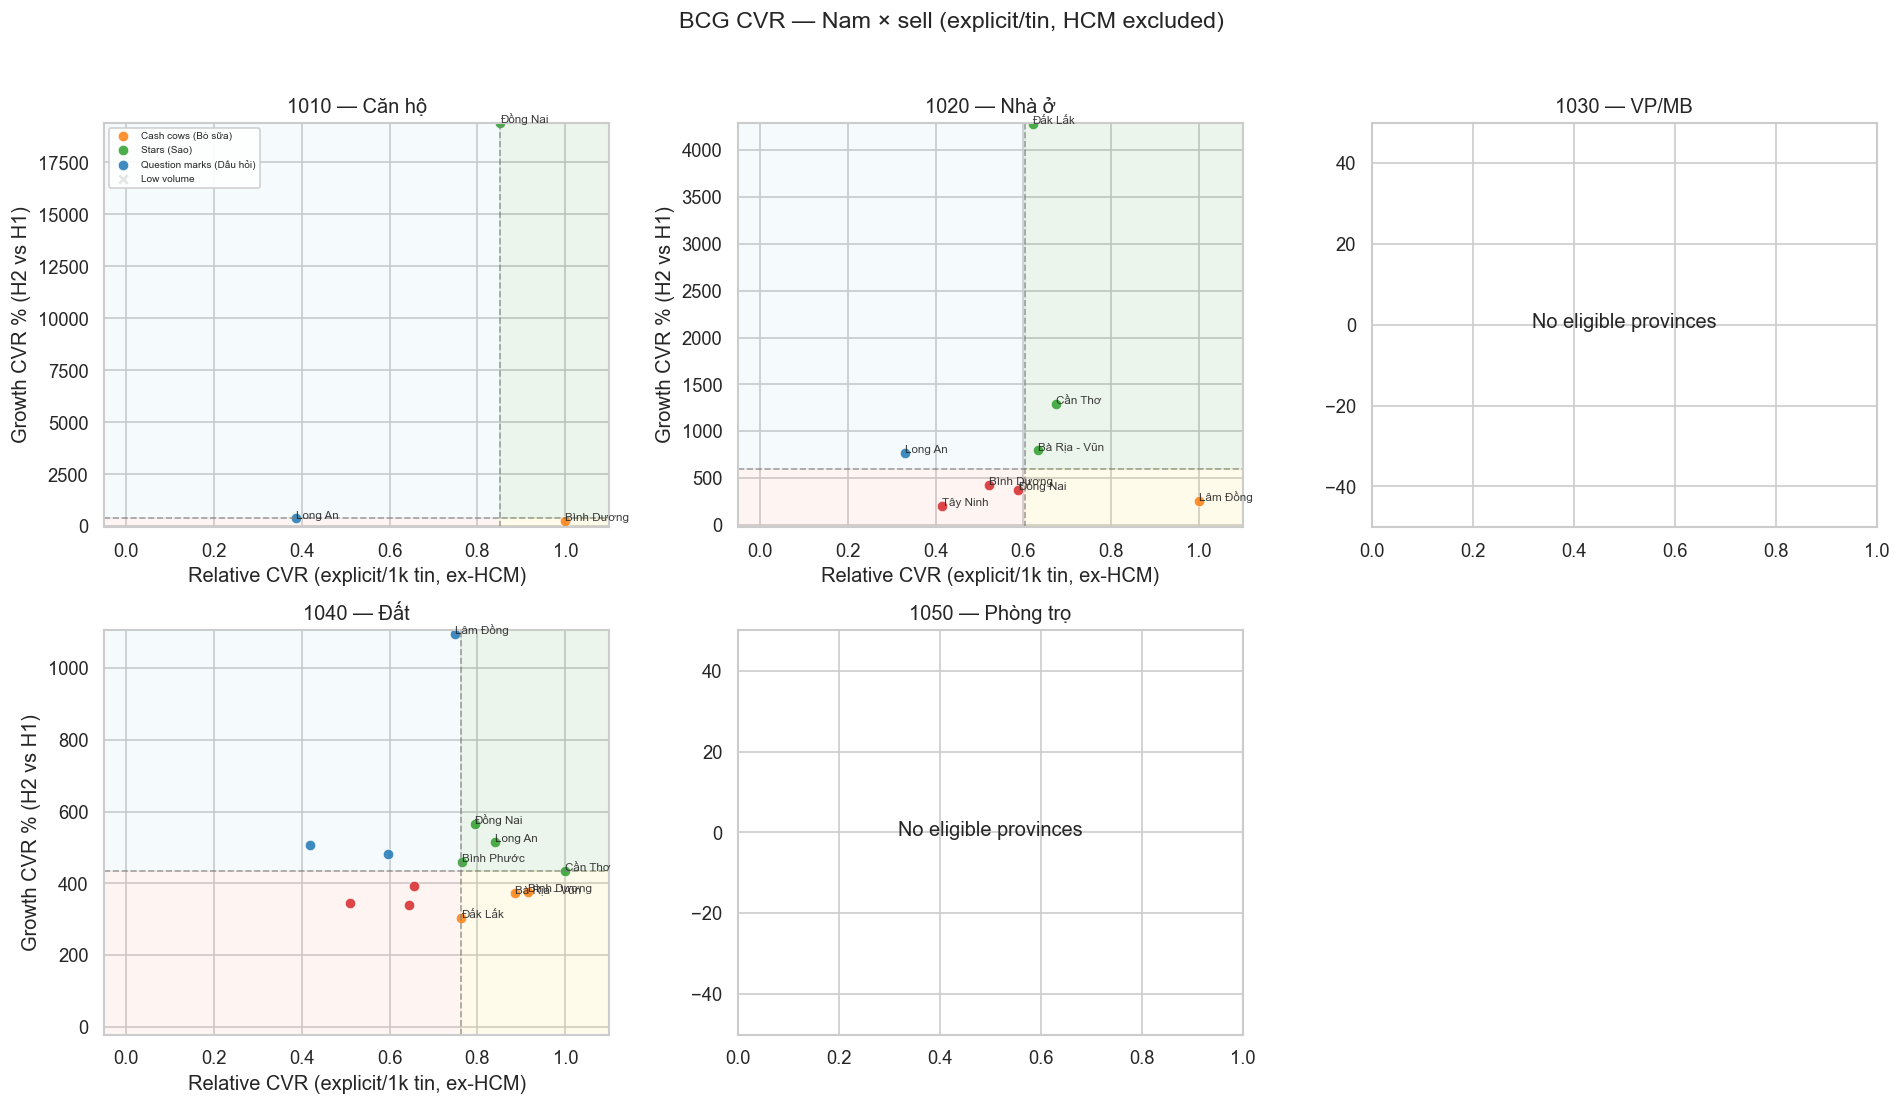

In [22]:
for region in mod.REGIONS:
    for ad_type in mod.AD_TYPES:
        path = OUT / f"fig_bcg_{region}_{ad_type}.png"
        if path.exists():
            display(Markdown(f"### {region} × {ad_type}"))
            display(Image(filename=str(path)))